In [49]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from src import get_singular_values, extract_rmt_parameters, fit_mp_to_density, gaussian_broadening, get_layer_from_checkpoint, run_spectral_analysis, get_layer_fingerprint
from IPython.display import HTML
from matplotlib.animation import FuncAnimation
from scipy.interpolate import CloughTocher2DInterpolator

SWEEP_PATH = Path("mlp_sweep")
HT32_PATH = Path("training_runs/mlp32_mnist/HT_alpha_1.2/GeneralMLP_LR0.001_BS128_20260222_113516_s0")
GAUSS32_PATH = Path("training_runs/mlp32_mnist/Gaussian_Baseline/GeneralMLP_LR0.001_BS128_20260222_113641_s0")
HT64_PATH = Path("training_runs/mlp64_mnist/HT_alpha_1.2/GeneralMLP_LR0.001_BS128_20260222_112717_s0")
GAUSS64_PATH = Path("training_runs/mlp64_mnist/Gaussian_Baseline/GeneralMLP_LR0.001_BS128_20260222_112842_s0")
HT128_PATH = Path("training_runs/mlp128_mnist/HT_alpha_1.2/GeneralMLP_LR0.001_BS128_20260222_111642_s0")
GAUSS128_PATH = Path("training_runs/mlp128_mnist/Gaussian_Baseline/GeneralMLP_LR0.001_BS128_20260222_111809_s0")
HT784_PATH = Path("training_runs/mlp784_mnist/HT_alpha_1.2/GeneralMLP_LR0.001_BS128_20260221_130323_s0")
GAUSS784_PATH = Path("training_runs/mlp784_mnist/Gaussian_Baseline/GeneralMLP_LR0.001_BS128_20260221_130451_s0")

HT_PATH = Path("mlp_sweep/alpha_1.2_g_1.0/GeneralMLP_LR0.001_BS128_20260228_135217_s0")
GAUSS_PATH = Path("mlp_sweep/alpha_2.0_g_1.0/GeneralMLP_LR0.001_BS128_20260228_143134_s0")

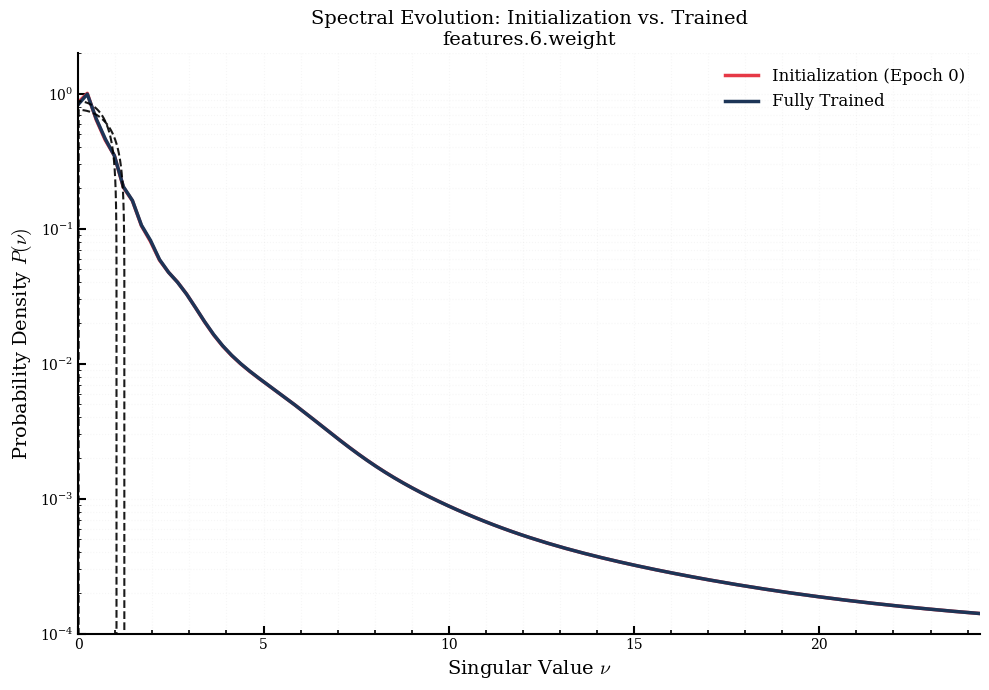

In [ ]:
# 1. Config & Paths
LAYER_KEY = 'features.6.weight'

# 2. Extract Final vs. Initialization (Epoch 0)
# We assume standard paths where your checkpoints are stored
W_final = get_layer_from_checkpoint(GAUSS_PATH / "final_model.pth", LAYER_KEY)
W_init  = get_layer_from_checkpoint(GAUSS_PATH / "checkpoints/weights_epoch_0.pth", LAYER_KEY)

# Extract raw singular values (nu) for both states [cite: 75, 224]
nu_final = get_singular_values(W_final)
nu_init  = get_singular_values(W_init)

# 3. Figure Generation
fig, ax = plt.subplots(figsize=(10, 7))

# Setup x-range slightly above 0 to avoid numerical singularities [cite: 79]
x_max = max(np.max(nu_final), np.max(nu_init)) * 1.1
x_range = np.linspace(1e-4, x_max, 1000)

data_configs = [
    (nu_init, W_init, 'Initialization (Epoch 0)', '#e63946'), # Red per Paper Fig 1
    (nu_final, W_final, 'Fully Trained', '#1d3557')            # Blue per Paper Fig 1
]

for nu, W, label, color in data_configs:
    # A. Empirical Density (Solid Line)
    empirical_pdf = gaussian_broadening(nu, x_range, a=15)
    ax.plot(x_range, empirical_pdf, color=color, lw=2.5, label=label)

    # B. RMT Parameters [cite: 83, 124]
    n, m, sigma_init = extract_rmt_parameters(W)
    Q = n / m
    v_max_fit, s_tilde_fit = fit_mp_to_density(x_range, empirical_pdf, nu)
    v_min_emp = np.min(nu)

    # C. Expanded MP Curve Evaluation
    # We create a specific high-resolution x-axis for the dashed line
    # starting exactly at v_min_emp to ensure it touches the axis.
    x_bulk = np.linspace(v_min_emp, v_max_fit, 500)

    term1 = Q / (np.pi * (s_tilde_fit**2) * x_bulk)
    term2 = np.sqrt(np.maximum(0, (v_max_fit**2 - x_bulk**2) * (x_bulk**2 - v_min_emp**2)))
    mp_pdf = np.nan_to_num(term1 * term2)

    # Plotting the Dashed Bulk [cite: 122]
    # This now spans the full theoretical support from v_min to v_max
    ax.plot(x_bulk, mp_pdf, color='black', linestyle='--', lw=1.5, alpha=0.9, zorder=3)

# 3. Aesthetics
ax.set_yscale('log')
ax.set_title(f"Spectral Evolution: Initialization vs. Trained\n{LAYER_KEY}", fontsize=14)
ax.set_xlabel(r'Singular Value $\nu$', fontsize=14)
ax.set_ylabel(r'Probability Density $P(\nu)$', fontsize=14)

# Set limits and spines per paper style
ax.set_ylim(1e-4, 2.0)
ax.set_xlim(0, x_max)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, which="both", ls=":", alpha=0.1)
ax.legend(frameon=False, loc='upper right', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
def plot_sweep_heatmap(data_source, metric='test_acc', stat='mean', layer_name=None, vmin=None, vmax=None):
    """
    Generates a high-fidelity interpolated phase diagram with manual color scaling.
    """
    # 1. Load Data
    if isinstance(data_source, (str, Path)):
        df = pd.read_csv(data_source)
    else:
        df = data_source

    # 2. Metric Resolution
    target_col = f"{metric}_{stat}"
    if target_col not in df.columns:
        print(f"Error: Column {target_col} not found.")
        return

    # 3. Filtering
    if layer_name and 'layer' in df.columns:
        sub_df = df[df['layer'] == layer_name].copy()
    else:
        sub_df = df.copy()

    sub_df = sub_df.dropna(subset=[target_col])

    alphas = sub_df['alpha'].values
    gs = sub_df['g'].values
    values = sub_df[target_col].values

    # 4. Interpolation
    points = np.column_stack((alphas, gs))
    interp_func = CloughTocher2DInterpolator(points, values)

    a_grid = np.linspace(alphas.min(), alphas.max(), 300)
    g_grid = np.linspace(gs.min(), gs.max(), 300)
    A, G = np.meshgrid(a_grid, g_grid)
    Z = interp_func(A, G)

    # 5. Rendering
    plt.figure(figsize=(10, 8), dpi=120)

    if stat in ['sem', 'pct_err']:
        cmap = 'Reds'
    else:
        cmap = 'magma'

    # Set dynamic or manual limits
    # vmin/vmax force the gradient to spread across your chosen range
    vmin = vmin if vmin is not None else np.nanmin(Z)
    vmax = vmax if vmax is not None else np.nanmax(Z)

    # Use extend='both' to handle values outside the vmin/vmax window
    cp = plt.contourf(A, G, Z, levels=100, cmap=cmap, vmin=vmin, vmax=vmax, extend='both')

    cbar = plt.colorbar(cp)
    cbar.set_label(f"{metric.replace('_', ' ').upper()} {stat.upper()}", fontsize=12)

    plt.scatter(alphas, gs, c='white', s=15, edgecolors='black',
                linewidths=0.5, alpha=0.4, label='Sampling Points')

    # Labeling
    title_suffix = f" | {layer_name}" if layer_name else ""
    plt.title(f"Performance Phase Map: {metric.upper()} {stat.upper()}{title_suffix}",
              fontsize=14, pad=20)
    plt.xlabel(r"Heavy-Tail Stability ($\alpha$)", fontsize=12)
    plt.ylabel(r"Variance Scaling ($g$)", fontsize=12)

    plt.tight_layout()
    plt.show()

# --- Example: Zooming in on the 0.90 to 0.98 accuracy range ---
PERF_PATH = "sweep_master_results_perf_summary.csv"
plot_sweep_heatmap(PERF_PATH, metric='test_acc', stat='mean', vmin=0.90, vmax=0.98)

In [ ]:
LAYER_KEY = 'features.2.weight'
# Automatically detect available checkpoints
EPOCHS = sorted([int(p.stem.split('_')[-1]) for p in (HT32_PATH / "checkpoints").glob("weights_epoch_*.pth")])

# --- PRE-SCAN FOR STATIC X-AXIS ---
print("Scanning checkpoints for global spectral bounds...")
global_max_lambda = 0
for epoch in EPOCHS:
    path = HT32_PATH / "checkpoints" / f"weights_epoch_{epoch}.pth"
    # Use verified singular value extraction (includes 1/M scaling)
    S_vals = get_singular_values(get_layer_from_checkpoint(path, LAYER_KEY))
    global_max_lambda = max(global_max_lambda, np.max(S_vals))

# 2. Initialize Persistent Figure
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_yscale('log')
ax.set_xlim(0, global_max_lambda * 1.05) # Static X-axis
ax.set_ylim(1e-3, 1e3)
ax.grid(True, which='both', alpha=0.05)

# Artists
hist_container = []
theory_line, = ax.plot([], [], 'r-', lw=2, label='MP Bulk Theory')
bulk_edge_line = ax.axvline(0, color='red', linestyle='--', alpha=0.5, label='Bulk Edge')

def update(epoch):
    """Update function for FuncAnimation using strict internal logic."""
    path = HT32_PATH / "checkpoints" / f"weights_epoch_{epoch}.pth"
    W = get_layer_from_checkpoint(path, LAYER_KEY)
    evs = get_singular_values(W) # S^2 / M

    # 1. Update Histogram
    global hist_container
    for patch in hist_container:
        patch.remove()

    counts, bins, hist_container = ax.hist(evs, bins=100, density=True,
                                            alpha=0.3, color='royalblue')

    # 2. Update Theoretical MP Law
    Q = W.shape[0] / W.shape[1]
    sigma_est = np.sqrt(np.mean(evs))
    x_range = np.linspace(1e-4, global_max_lambda * 1.05, 500)
    pdf, _, l_max = marchenko_pastur_pdf(x_range, Q, sigma=sigma_est)

    theory_line.set_data(x_range, pdf)
    bulk_edge_line.set_xdata([l_max])

    ax.set_title(f"Spectral Evolution: {LAYER_KEY} (Static Axis)\nEpoch {epoch} | $\\alpha=1.2$")
    return theory_line, bulk_edge_line, *hist_container

# 3. Build and Display
ani = FuncAnimation(fig, update, frames=EPOCHS, blit=False)
plt.close() # Prevent extra static plot
HTML(ani.to_jshtml())

In [ ]:
LAYERS = ['features.0.weight', 'features.2.weight', 'classifier.weight']
EPOCHS = range(0, 160, 10)

def get_layer_rotations(run_dir, layers, epochs):
    """Calculates cosine similarity between the top singular vector at epoch 0 vs. t."""
    results = {layer: [] for layer in layers}

    for layer in layers:
        # Load Reference State (Epoch 0) using strict analysis tools
        W0 = get_layer_from_checkpoint(run_dir / "checkpoints/weights_epoch_0.pth", layer)
        _, _, Vt0 = torch.svd(W0)
        v0 = Vt0[:, 0] # Principal right-singular vector

        for epoch in epochs:
            ckpt_path = run_dir / "checkpoints" / f"weights_epoch_{epoch}.pth"
            if not ckpt_path.exists():
                results[layer].append(None)
                continue

            # Load Target State
            Wt = get_layer_from_checkpoint(ckpt_path, layer)
            _, _, Vtt = torch.svd(Wt)
            vt = Vtt[:, 0]

            # Cosine Similarity (absolute value to ignore phase flips)
            similarity = torch.abs(torch.dot(v0, vt)).item()
            results[layer].append(similarity)

    return results

# 2. Execution
ht_rotations = get_layer_rotations(HT32_PATH, LAYERS, EPOCHS)
ga_rotations = get_layer_rotations(GAUSS32_PATH, LAYERS, EPOCHS)

# 3. Visualization Suite
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
run_styles = [
    (ht_rotations, '#1f77b4', 'o', 'HT (α=1.2)'),
    (ga_rotations, '#d62728', 's', 'Gaussian (α=2.0)')
]

for i, layer in enumerate(LAYERS):
    ax = axes[i]
    for results, color, marker, label in run_styles:
        ax.plot(EPOCHS, results[layer], color=color, marker=marker,
                label=f"{label} {layer}", markersize=4, alpha=0.8)

    ax.axhline(1.0, color='black', alpha=0.2, linestyle='--')
    ax.set_title(f"Layer: {layer}", fontweight='bold')
    ax.set_xlabel("Epoch")
    ax.grid(True, which='both', alpha=0.1)

    if i == 0:
        ax.set_ylabel("Top Eigenvector Cosine Similarity")
    ax.legend(fontsize='small')

plt.tight_layout()
plt.show()

In [ ]:
# 1. Paths & Configuration
# Assuming master config is two levels up from the run leaf
CONFIG_PATH = HT784_PATH.parent.parent / "mlp784_mnist.yaml"
LAYERS = ['features.0.weight', 'features.2.weight', 'classifier.weight']
K_VALUES = list(range(0, 11))

# 2. Execution and Plotting Loop
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, layer in enumerate(LAYERS):
    ax = axes[i]
    print(f"Executing sweep for {layer}...")

    # Automated parent wrapper handles data loading and model factory
    ht_raw = run_spectral_analysis(HT784_PATH, CONFIG_PATH, layer, K_VALUES, mode='ablate')
    ga_raw = run_spectral_analysis(GAUSS784_PATH, CONFIG_PATH, layer, K_VALUES, mode='ablate')

    # Extract accuracies from the result dictionaries
    ht_accs = [r['accuracy'] for r in ht_raw]
    ga_accs = [r['accuracy'] for r in ga_raw]

    # Visualization
    ax.plot(K_VALUES, ht_accs, 'b-o', label='HT (Lévy α=1.2)', linewidth=2)
    ax.plot(K_VALUES, ga_accs, 'r-s', label='Gaussian (α=2.0)', linewidth=2)

    # Formatting
    ax.axhline(0.1, color='black', linestyle='--', alpha=0.3, label='Chance')
    ax.set_title(f"Ablation: {layer}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Top-K Singular Values Removed", fontsize=11)
    ax.grid(True, which='both', alpha=0.1)

    if i == 0:
        ax.set_ylabel("Validation Accuracy", fontsize=11)
    if i == 2:
        ax.legend(frameon=True, loc='lower left', fontsize='small')

plt.suptitle("Spectral Sensitivity Across Architecture Depth", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [10]:
def analyze_run(run_path, layers):
    """
    Analyzes a training run by comparing the final state to initialization
    using standardized fingerprinting.
    """
    results = []

    # Checkpoints for comparison to calculate displacement and stability
    init_path = run_path / "checkpoints" / "weights_epoch_0.pth"
    final_path = run_path / "final_model.pth"

    for layer in layers:
        # Strict usage of analysis utilities
        W_init = get_layer_from_checkpoint(init_path, layer)
        W_final = get_layer_from_checkpoint(final_path, layer)

        # Computes IPR, Eff Rank, Displacement, and PR in one pass
        metrics = get_layer_fingerprint(W_init, W_final)
        metrics['layer'] = layer
        results.append(metrics)

    return pd.DataFrame(results)

# 1. Config Paths
LAYERS = ['features.0.weight', 'features.2.weight', 'classifier.weight']

# 2. Execution
ht_df = analyze_run(HT784_PATH, LAYERS)
ga_df = analyze_run(GAUSS784_PATH, LAYERS)

# 3. Output
print("--- Heavy-Tailed (HT) Spectral Fingerprint ---")
print(ht_df[['layer', 'ipr', 'effective_rank', 'displacement', 'participation_ratio', 'hill_alpha', 'spectral_entropy', 'dominance_ratio']])

print("\n--- Gaussian (GA) Spectral Fingerprint ---")
print(ga_df[['layer', 'ipr', 'effective_rank', 'displacement', 'participation_ratio', 'hill_alpha', 'spectral_entropy', 'dominance_ratio']])

--- Heavy-Tailed (HT) Spectral Fingerprint ---
               layer       ipr  effective_rank  displacement  \
0  features.0.weight  0.999840        2.919669      0.024345   
1  features.2.weight  0.999620        2.667165      0.023311   
2  classifier.weight  0.670394        1.616672      0.099987   

   participation_ratio  hill_alpha  spectral_entropy  dominance_ratio  
0             0.093266    1.564807          2.407018         0.068441  
1             0.148535    1.373689          3.178256         0.056742  
2             0.680694    2.351194          1.477061         0.301448  

--- Gaussian (GA) Spectral Fingerprint ---
               layer       ipr  effective_rank  displacement  \
0  features.0.weight  0.003917      190.032913      0.104797   
1  features.2.weight  0.003748      189.991882      0.084460   
2  classifier.weight  0.004411        8.235638      0.097600   

   participation_ratio  hill_alpha  spectral_entropy  dominance_ratio  
0             0.719295   10.789156 

In [27]:
def aggregate_sweep_stats(sweep_root, layers, output_name="sweep_master_results.csv"):
    """
    Crawls sweep directory, computes fingerprints, and generates
    summary statistics (Mean, Median, SEM).
    """
    layer_results = []
    perf_results = []
    sweep_root = Path(sweep_root)

    # Define SEM as a proper function so Pandas names the column 'sem'
    def sem(x):
        return x.std() / np.sqrt(len(x)) if len(x) > 0 else np.nan

    # 1. Extraction Loop
    for param_dir in sweep_root.iterdir():
        if not param_dir.is_dir(): continue
        try:
            parts = param_dir.name.split('_')
            alpha, g = float(parts[1]), float(parts[3])
        except (IndexError, ValueError): continue

        for run_path in param_dir.iterdir():
            if not run_path.is_dir(): continue

            # --- Performance Data (Model-wide) ---
            log_path = run_path / "train_log.csv"
            test_acc = np.nan
            if log_path.exists():
                try:
                    log_df = pd.read_csv(log_path)
                    if not log_df.empty:
                        test_acc = log_df.sort_values('epoch').iloc[-1]['test_acc']
                except: pass

            perf_results.append({'alpha': alpha, 'g': g, 'run_name': run_path.name, 'test_acc': test_acc})

            # --- Spectral Data (Layer-specific) ---
            init_path = run_path / "checkpoints" / "weights_epoch_0.pth"
            final_path = run_path / "final_model.pth"
            if not (init_path.exists() and final_path.exists()): continue

            for layer in layers:
                try:
                    W_0 = get_layer_from_checkpoint(init_path, layer)
                    W_T = get_layer_from_checkpoint(final_path, layer)
                    metrics = get_layer_fingerprint(W_0, W_T)
                    metrics.update({'alpha': alpha, 'g': g, 'layer': layer, 'run_name': run_path.name})
                    layer_results.append(metrics)
                except Exception as e: print(f"Error {layer}: {e}")

    # 2. Convert to DataFrames
    ldf = pd.DataFrame(layer_results)
    pdf = pd.DataFrame(perf_results)

    # 3. Aggregate Layer Stats
    spec_cols = ['participation_ratio', 'displacement', 'effective_rank', 'ipr', 'hill_alpha', 'spectral_entropy', 'dominance_ratio']
    spec_summary = ldf.groupby(['alpha', 'g', 'layer'])[spec_cols].agg(['mean', 'median', sem])

    # Flatten MultiIndex safely: ('ipr', 'mean') -> 'ipr_mean'
    spec_summary.columns = [f"{col}_{stat}" for col, stat in spec_summary.columns]
    spec_summary = spec_summary.reset_index()

    # 4. Aggregate Performance Stats (Exactly 1 row per alpha/g)
    perf_summary = pdf.groupby(['alpha', 'g'])['test_acc'].agg(['mean', 'median', sem])
    perf_summary.columns = ['test_acc_mean', 'test_acc_median', 'test_acc_sem']
    perf_summary = perf_summary.reset_index()

    # 5. Add PCT_ERR
    for col in spec_cols:
        spec_summary[f'{col}_pct_err'] = (spec_summary[f'{col}_sem'] / spec_summary[f'{col}_mean'].replace(0, np.nan)) * 100

    perf_summary['test_acc_pct_err'] = (perf_summary['test_acc_sem'] / perf_summary['test_acc_mean'].replace(0, np.nan)) * 100

    # 6. Export
    ldf.to_csv(output_name, index=False)
    spec_summary.to_csv(output_name.replace(".csv", "_spec_summary.csv"), index=False)
    perf_summary.to_csv(output_name.replace(".csv", "_perf_summary.csv"), index=False)

    return spec_summary, perf_summary

# --- Execution ---
# Updated for your proposed 5-layer depth
LAYERS = [
    'features.0.weight',
    'features.2.weight',
    'features.4.weight',
    'features.6.weight',
    'classifier.weight'
]

master_df = aggregate_sweep_stats(SWEEP_PATH, LAYERS)

In [ ]:
def plot_universality_heatmap(data_source, layer_name, metric='participation_ratio', stat='mean'):
    """
    Produces an interpolated phase map.

    Args:
        data_source (str/Path/pd.DataFrame): The summary stats to visualize.
        layer_name (str): The specific layer (e.g., 'classifier.weight').
        metric (str): The fingerprint metric (e.g., 'participation_ratio').
        stat (str): The statistic type: 'mean', 'median', 'sem', or 'pct_err'.
        smooth (float): Smoothing factor to handle seed-level noise.
    """
    # 1. Robust Data Loading
    if isinstance(data_source, (str, Path)):
        if not Path(data_source).exists():
            print(f"Error: File {data_source} not found.")
            return
        df = pd.read_csv(data_source)
    else:
        df = data_source

    # 2. Dynamic Column Selection
    target_col = f"{metric}_{stat}"
    if target_col not in df.columns:
        available = [c for c in df.columns if metric in c]
        print(f"Error: Column '{target_col}' not found. Available: {available}")
        return

    # 3. Filtering and Prep
    sub_df = df[df['layer'] == layer_name].copy().dropna(subset=[target_col])
    if sub_df.empty:
        print(f"Error: No data found for layer '{layer_name}'.")
        return

    alphas = sub_df['alpha'].values
    gs = sub_df['g'].values
    values = sub_df[target_col].values

    # 4. Clough-Tocher Interpolation
    # This method uses a Delaunay triangulation of quincunx points.
    points = np.column_stack((alphas, gs))
    interp_func = CloughTocher2DInterpolator(points, values)

    # Generate a high-resolution grid for the visual surface
    alpha_grid = np.linspace(alphas.min(), alphas.max(), 200)
    g_grid = np.linspace(gs.min(), gs.max(), 200)
    A, G = np.meshgrid(alpha_grid, g_grid)

    # Compute the interpolated values across the mesh
    # We use a combined array for the query points
    Z = interp_func(A, G)

    # 5. Plotting
    plt.figure(figsize=(9, 7), dpi=120)

    # Use 'magma' for metrics and 'Reds' for instability (SEM/PCT_ERR)
    cmap = 'magma' if stat not in ['sem', 'pct_err'] else 'Reds'

    # Clough-Tocher ensures the transition ridge is a solid vertical band
    cp = plt.contourf(A, G, Z, levels=100, cmap=cmap)

    cbar = plt.colorbar(cp)
    cbar.set_label(f"{metric.replace('_', ' ').title()} ({stat.upper()})", fontsize=11)

    # Overlay the quincunx/grid points
    plt.scatter(alphas, gs, c='white', s=25, edgecolors='black', linewidths=0.8, alpha=0.5, label='Sampling Points')

    plt.title(f"Phase Diagram (Clough-Tocher): {layer_name}\n{metric.upper()} {stat.upper()}", fontsize=14, pad=15)
    plt.xlabel(r"Heavy-Tail Stability ($\alpha$)", fontsize=12)
    plt.ylabel(r"Variance Scaling ($g$)", fontsize=12)

    plt.tight_layout()
    plt.show()

# --- Example Usage ---
SUMMARY_PATH = "sweep_master_results_spec_summary.csv"
plot_universality_heatmap(SUMMARY_PATH, 'features.2.weight', metric='effective_rank', stat='pct_err')

In [ ]:
def plot_phase_slice(data_source, layer_name, slice_axis='alpha', fixed_val=1.8, metric='effective_rank_pct_err'):
    """
    Cuts a 1D slice through the phase diagram.

    Args:
        slice_axis (str): 'alpha' to slice at a fixed alpha (Vertical),
                         'g' to slice at a fixed g (Horizontal).
        fixed_val (float): The coordinate to lock (e.g., 1.8 for the ridge).
    """
    df = pd.read_csv(data_source) if isinstance(data_source, str) else data_source

    # 1. Filter for Layer
    sub = df[df['layer'] == layer_name].copy()

    # 2. Identify the Slice
    # We use a small epsilon for float comparison to catch our grid points
    if slice_axis == 'alpha':
        slice_df = sub[np.isclose(sub['alpha'], fixed_val, atol=1e-3)]
        x_col, xlabel = 'g', r"Variance Scaling ($g$)"
        title = f"Vertical Slice at $\\alpha={fixed_val}$"
    else:
        slice_df = sub[np.isclose(sub['g'], fixed_val, atol=1e-3)]
        x_col, xlabel = 'alpha', r"Heavy-Tail Stability ($\alpha$)"
        title = f"Horizontal Slice at $g={fixed_val}$"

    if slice_df.empty:
        print(f"Error: No data found at {slice_axis}={fixed_val}. Check your grid values.")
        return

    # 3. Sort for a clean line plot
    slice_df = slice_df.sort_values(x_col)

    # 4. Plotting
    plt.figure(figsize=(10, 5), dpi=100)

    # 1. Tighten the Y-axis to the data range
    # This forces the plot to show the subtle 'Resonance Peaks'
    plt.ylim(slice_df[metric].min() - 0.5, slice_df[metric].max() + 0.5)

    # 2. Add high-precision markers
    plt.plot(slice_df[x_col], slice_df[metric], marker='D', markersize=6)

    # We plot the pct_err directly to see the "resonance" peaks
    plt.plot(slice_df[x_col], slice_df[metric], marker='o', linestyle='-',
             linewidth=2, color='#8B0000', label=metric.upper())

    plt.fill_between(slice_df[x_col], 0, slice_df[metric], alpha=0.1, color='red')

    plt.title(f"{title}: {layer_name}\nMetric: {metric.replace('_', ' ').upper()}", fontsize=13)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel("Relative Volatility (%)", fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.legend()

    plt.tight_layout()
    plt.show()

def plot_performance_slice(data_source, slice_axis='alpha', fixed_val=1.9, metric='test_acc_mean'):
    """
    Slices the global performance data (Accuracy) independently of layers.
    """
    df = pd.read_csv(data_source) if isinstance(data_source, str) else data_source

    # Identify the Slice
    if slice_axis == 'alpha':
        slice_df = df[np.isclose(df['alpha'], fixed_val, atol=1e-3)]
        x_col, xlabel = 'g', r"Variance Scaling ($g$)"
    else:
        slice_df = df[np.isclose(df['g'], fixed_val, atol=1e-3)]
        x_col, xlabel = 'alpha', r"Heavy-Tail Stability ($\alpha$)"

    slice_df = slice_df.sort_values(x_col)

    # Plotting
    plt.figure(figsize=(10, 5), dpi=100)

    plt.plot(slice_df[x_col], slice_df[metric], marker='s', linestyle='-',
             linewidth=2, color='#00008B', label=metric.upper())

    plt.title(f"Performance Slice at {slice_axis}={fixed_val}\nMetric: {metric.upper()}", fontsize=13)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel("Test Accuracy", fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- Example Usage ---
plot_performance_slice("sweep_master_results_perf_summary.csv",
                       slice_axis='alpha',
                       fixed_val=1.9,
                       metric='test_acc_pct_err')

# --- Example Usage for the Ridge ---
plot_phase_slice("sweep_master_results_spec_summary.csv",
                 layer_name="features.0.weight",
                 slice_axis='alpha',
                 fixed_val=1.9,
                 metric='effective_rank_pct_err')

In [ ]:
def plot_alpha_depth_profile(data_source, target_g, alpha_list=[1.0, 1.2, 1.4, 1.6, 1.8, 2.0], metric='participation_ratio', exclude_gaussian=True):
    """
    Plots the layer-wise evolution of a spectral metric for a fixed g.

    Args:
        data_source (str or pd.DataFrame): Path to summary CSV or the DataFrame itself.
        target_g (float): The specific variance scaling value to isolate.
        alpha_list (list): The alpha values to compare.
        metric (str): The metric to plot (e.g., 'participation_ratio', 'ipr', 'effective_rank').
    """
    # 1. Load summary data
    df = pd.read_csv(data_source) if isinstance(data_source, (str, Path)) else data_source

    # 2. Define the structural order of your layers
    layer_order = [
        'features.0.weight',
        'features.2.weight',
        'features.4.weight',
        'features.6.weight',
        'classifier.weight'
    ]

    # Define cleaner labels for the x-axis
    display_labels = ['$L_0$', '$L_1$', '$L_2$', '$L_3$', 'Cls']

    plt.figure(figsize=(10, 6), dpi=100)

    # 3. Filter and Plot
    # We isolate the specific g and then iterate through the alpha values
    for alpha in alpha_list:
        if exclude_gaussian and alpha >= 2.0:
            continue
        # Get mean and SEM for this specific (alpha, g) pair across all layers
        subset = df[(df['g'] == target_g) & (df['alpha'] == alpha)]

        if subset.empty:
            print(f"Warning: No data found for $\alpha$={alpha}, $g$={target_g}")
            continue

        # Reorder metrics to match the physical depth of the network
        subset = subset.set_index('layer').reindex(layer_order)

        means = subset[f'{metric}_mean'].values
        sems = subset[f'{metric}_sem'].values

        # Plot with error bars to show the stability of the phase at each depth
        plt.errorbar(
            range(len(layer_order)),
            means,
            yerr=sems,
            label=f"$\\alpha$={alpha}",
            capsize=4,
            marker='o',
            markersize=8,
            linewidth=2,
            alpha=0.8
        )

    # 4. Aesthetics and Formatting
    plt.title(f"Depth Profile: {metric.replace('_', ' ').title()} ($g$={target_g})", fontsize=14, pad=15)
    plt.xlabel("Network Depth", fontsize=12)
    plt.ylabel(f"{metric.replace('_', ' ').title()} (Mean $\\pm$ SEM)", fontsize=12)
    plt.xticks(range(len(layer_order)), display_labels)

    plt.legend(title="Tail Stability ($\\alpha$)", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

# --- Example Usage ---
SUMMARY_CSV = 'sweep_master_results_summary.csv'
plot_alpha_depth_profile(SUMMARY_CSV, target_g=1.0, metric='hill_alpha')